In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

### Resultados de las simulaciones a nivel global

#### Carga de datos

In [126]:
df_global = pd.read_json("resultados_globales.json")
df_global.head()

,replica,duracion_simulacion,tiempo_escape_promedio
0,1,12,6.000000
1,2,13,4.777778
2,3,12,5.777778
3,4,15,5.222222
4,5,13,4.625000


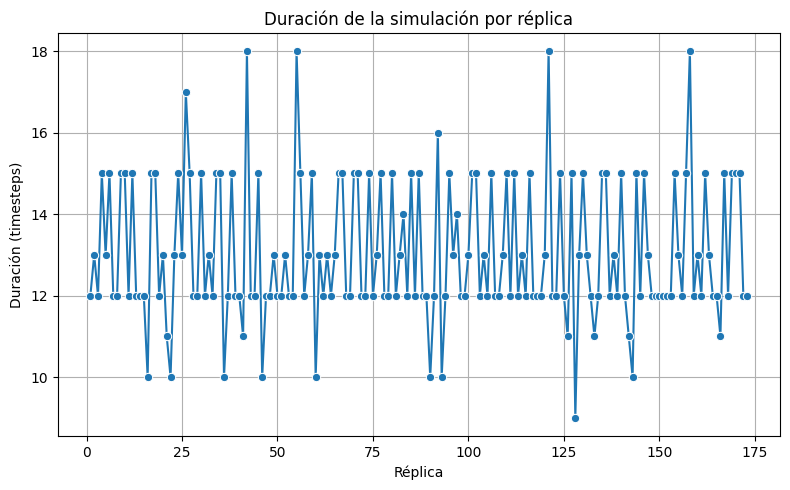

In [127]:
plt.figure(figsize=(8,5))
sns.lineplot(x="replica", y="duracion_simulacion", data=df_global, marker="o")
plt.title("Duración de la simulación por réplica")
plt.xlabel("Réplica")
plt.ylabel("Duración (timesteps)")
plt.grid(True)
plt.tight_layout()
plt.show()

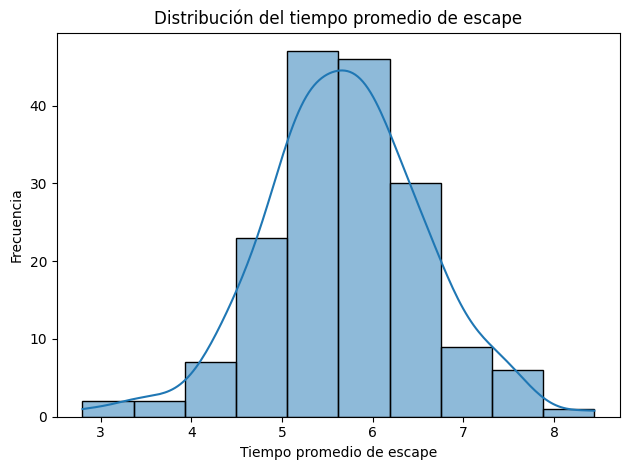

In [128]:
sns.histplot(df_global["tiempo_escape_promedio"].dropna(), kde=True, bins=10)
plt.title("Distribución del tiempo promedio de escape")
plt.xlabel("Tiempo promedio de escape")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


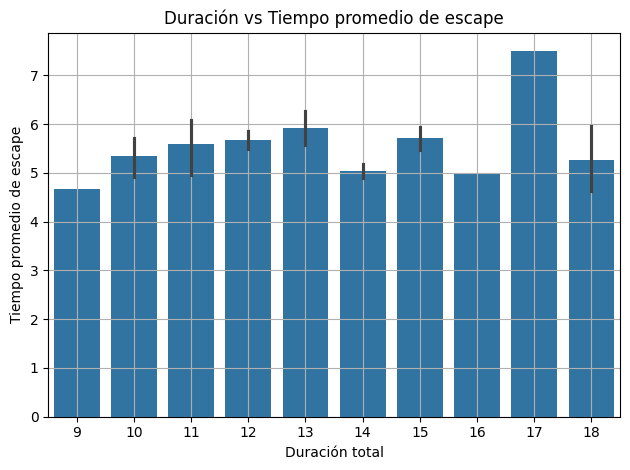

In [129]:
sns.barplot(x="duracion_simulacion", y="tiempo_escape_promedio", data=df_global)
plt.title("Duración vs Tiempo promedio de escape")
plt.xlabel("Duración total")
plt.ylabel("Tiempo promedio de escape")
plt.grid(True)
plt.tight_layout()
plt.show()

In [130]:
df_global[["duracion_simulacion", "tiempo_escape_promedio"]].describe()

,duracion_simulacion,tiempo_escape_promedio
count,173.000000,173.000000
mean,13.040462,5.693681
std,1.709612,0.875264
min,9.000000,2.800000
25%,12.000000,5.153846
50%,12.000000,5.700000
75%,15.000000,6.250000
max,18.000000,8.444444


In [96]:
correlacion = df_global[["duracion_simulacion", "tiempo_escape_promedio"]].corr()
print("Matriz de correlación:")
display(correlacion)

Matriz de correlación:


,duracion_simulacion,tiempo_escape_promedio
duracion_simulacion,1.000000,0.052353
tiempo_escape_promedio,0.052353,1.000000


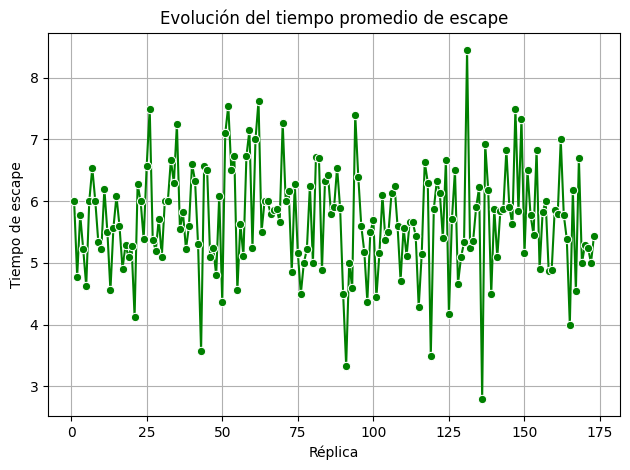

In [131]:
sns.lineplot(x="replica", y="tiempo_escape_promedio", data=df_global, marker="o", color="green")
plt.title("Evolución del tiempo promedio de escape")
plt.xlabel("Réplica")
plt.ylabel("Tiempo de escape")
plt.grid(True)
plt.tight_layout()
plt.show()


### Resultados de simulaciones por agente

#### Carga de datos

In [98]:
results = pd.read_json("./resultados_agentes.json")

results.head()
results.info()
results.describe()
results.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6920 entries, 0 to 6919
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   replica           6920 non-null   int64 
 1   id                6920 non-null   int64 
 2   tipo              6920 non-null   object
 3   estado            6920 non-null   object
 4   tiempo_total      6920 non-null   int64 
 5   espera_total      6920 non-null   int64 
 6   espera_salida     6920 non-null   int64 
 7   espera_escaleras  6920 non-null   int64 
 8   pasos_panico      6920 non-null   int64 
 9   puerta_salida     1624 non-null   object
 10  escaleras_usadas  6920 non-null   object
 11  historial_humo    6920 non-null   object
dtypes: int64(7), object(5)
memory usage: 648.9+ KB


,replica,id,tipo,estado,tiempo_total,espera_total,espera_salida,espera_escaleras,pasos_panico,puerta_salida,escaleras_usadas,historial_humo
count,6920.000000,6920.000000,6920,6920,6920.000000,6920.0,6920.0,6920.0,6920.0,1624,6920,6920
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,1,1,1017
top,NaN,NaN,niño,dead,NaN,NaN,NaN,NaN,NaN,"[6, 8, 0]",[],[alto]
freq,NaN,NaN,2367,5293,NaN,NaN,NaN,NaN,NaN,1624,6920,741
mean,87.000000,19.500000,NaN,NaN,6.190607,0.0,0.0,0.0,0.0,NaN,NaN,NaN
std,49.943573,11.544231,NaN,NaN,3.187034,0.0,0.0,0.0,0.0,NaN,NaN,NaN
min,1.000000,0.000000,NaN,NaN,1.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN
25%,44.000000,9.750000,NaN,NaN,4.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN
50%,87.000000,19.500000,NaN,NaN,6.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN
75%,130.000000,29.250000,NaN,NaN,9.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN


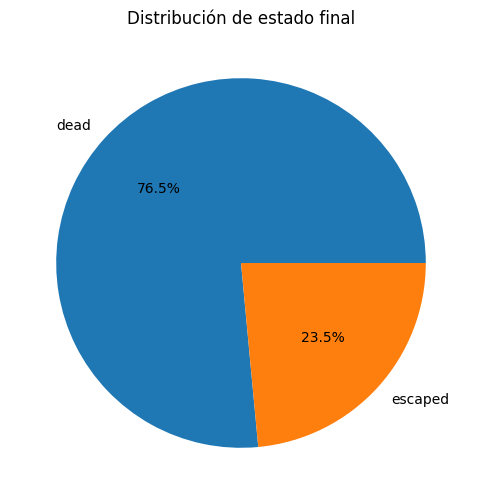

In [100]:
#estados finales de los agentes
estado_counts = results["estado"].value_counts(normalize=True)
estado_counts.plot.pie(autopct="%1.1f%%", title="Distribución de estado final", figsize=(6,6))
plt.ylabel("")
plt.show()

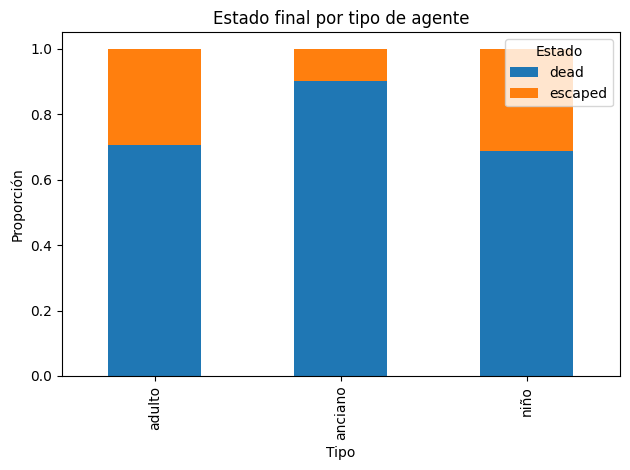

In [101]:
# muertes, escape por tipos de agentes
estado_por_tipo = results.groupby("tipo")["estado"].value_counts(normalize=True).unstack()
estado_por_tipo.plot.bar(stacked=True, title="Estado final por tipo de agente")
plt.xlabel("Tipo")
plt.ylabel("Proporción")
plt.legend(title="Estado")
plt.tight_layout()
plt.show()


In [102]:
results.groupby("tipo")[["espera_total", "espera_salida", "espera_escaleras", "pasos_panico"]].mean()


,espera_total,espera_salida,espera_escaleras,pasos_panico
tipo,,,,
adulto,0.0,0.0,0.0,0.0
anciano,0.0,0.0,0.0,0.0
niño,0.0,0.0,0.0,0.0


C:\Users\ma907\AppData\Local\Temp\ipykernel_54196\3014738166.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="estado", y="tiempo_total", data=results, palette="Set2")


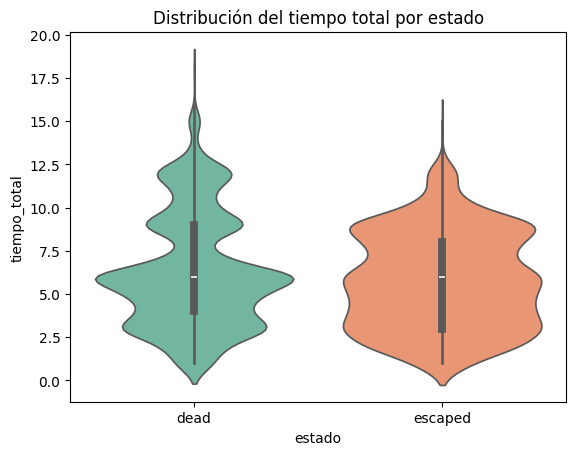

In [103]:
sns.violinplot(x="estado", y="tiempo_total", data=results, palette="Set2")
plt.title("Distribución del tiempo total por estado")
plt.show()

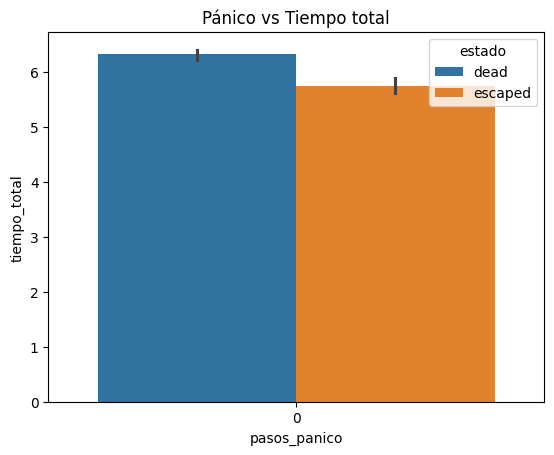

In [104]:
sns.barplot(x="pasos_panico", y="tiempo_total", hue="estado", data=results)
plt.title("Pánico vs Tiempo total")
plt.show()


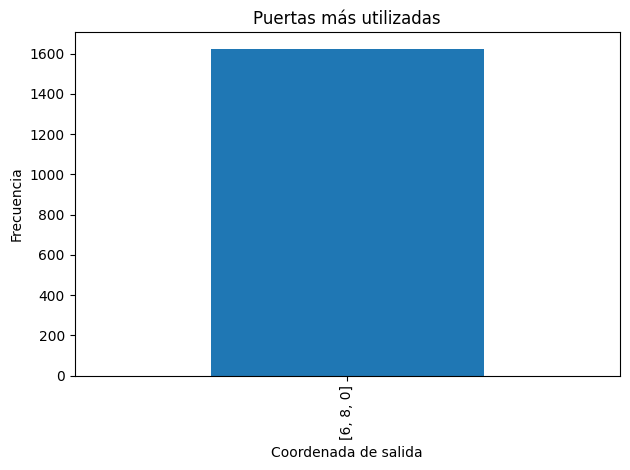

In [105]:
puertas = results[results["puerta_salida"].notna()]["puerta_salida"].value_counts()
puertas.plot.bar(title="Puertas más utilizadas")
plt.xlabel("Coordenada de salida")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


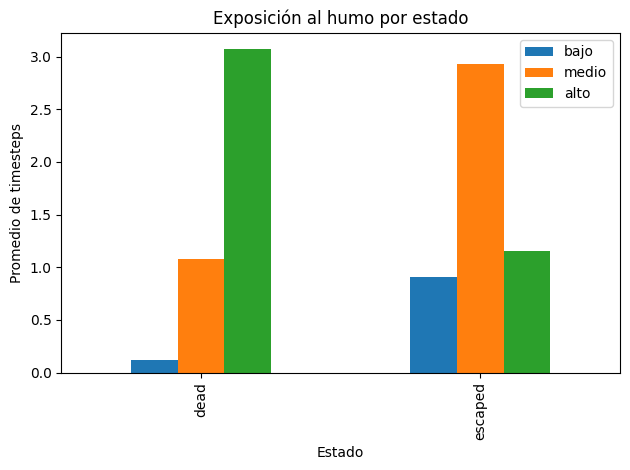

In [106]:
def contar_humo(historial):
    return {
        "bajo": historial.count("bajo"),
        "medio": historial.count("medio"),
        "alto": historial.count("alto"),
        "total": len(historial)
    }

df_humo = results["historial_humo"].apply(contar_humo).apply(pd.Series)
df = pd.concat([results, df_humo], axis=1)

df.groupby("estado")[["bajo", "medio", "alto"]].mean().plot.bar(title="Exposición al humo por estado")
plt.xlabel("Estado")
plt.ylabel("Promedio de timesteps")
plt.tight_layout()
plt.show()



In [107]:
results.groupby("tipo")[["tiempo_total", "espera_total", "espera_salida", "espera_escaleras", "pasos_panico"]].mean()


,tiempo_total,espera_total,espera_salida,espera_escaleras,pasos_panico
tipo,,,,,
adulto,5.505778,0.0,0.0,0.0,0.0
anciano,7.473730,0.0,0.0,0.0,0.0
niño,5.593156,0.0,0.0,0.0,0.0


In [108]:
resumen = results.groupby("tipo")["estado"].value_counts(normalize=True).unstack().fillna(0)
resumen_porcentual = (resumen * 100).round(2)
resumen_porcentual = resumen_porcentual[["dead", "escaped"]]
print("Porcentaje de 'dead' y 'escaped' por tipo de agente:")
display(resumen_porcentual)


Porcentaje de 'dead' y 'escaped' por tipo de agente:


estado,dead,escaped
tipo,,
adulto,70.58,29.42
anciano,90.10,9.90
niño,68.86,31.14


## Deeper statistical analysis

##### Todos los tipos de agentes escapan con la misma tasa?

In [109]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(results["tipo"], results["estado"])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f"Chi² = {chi2:.2f}, p = {p:.4f}")
residuals = (tabla - expected) / np.sqrt(expected)
residuals.round(2)

Chi² = 357.49, p = 0.0000


estado,dead,escaped
tipo,,
adulto,-3.21,5.78
anciano,7.47,-13.47
niño,-4.24,7.65


##### Tiempo de escape entre tipos difiere?

In [110]:
from scipy.stats import f_oneway
df = results
adultos = df[df["tipo"] == "adulto"]["tiempo_total"]
niños = df[df["tipo"] == "niño"]["tiempo_total"]
ancianos = df[df["tipo"] == "anciano"]["tiempo_total"]

f_stat, p_val = f_oneway(adultos, niños, ancianos)
print(f"F = {f_stat:.2f}, p = {p_val:.4f}")

F = 304.79, p = 0.0000


#### El humo influye en los resultados

In [111]:
def contar_humo(historial):
    return {
        "bajo": historial.count("bajo"),
        "medio": historial.count("medio"),
        "alto": historial.count("alto"),
        "total": len(historial)
    }

df_humo = results["historial_humo"].apply(contar_humo).apply(pd.Series)
df = pd.concat([results, df_humo], axis=1)


from scipy.stats import mannwhitneyu

muertos = df[df["estado"] == "dead"]["alto"]
escapados = df[df["estado"] == "escaped"]["alto"]

u_stat, p_val = mannwhitneyu(muertos, escapados, alternative="two-sided")
print(f"U = {u_stat:.2f}, p = {p_val:.4f}")


U = 7071995.00, p = 0.0000


Test de Kolmogorov smirnov para prueba de normalidad

In [ ]:
from scipy.stats import kstest, norm
valores = df_global["tiempo_escape_promedio"].dropna()

media = valores.mean()
std = valores.std()

stat, p_value = kstest(valores, "norm", args=(media, std))

print(f"Kolmogorov–Smirnov Test:")
print(f"Estadístico = {stat:.4f}")
print(f"Valor p     = {p_value:.4f}")

if p_value > 0.05:
    print("No se rechaza la hipótesis nula: los datos podrían seguir una distribución normal.")
else:
    print("Se rechaza la hipótesis nula: los datos no parecen seguir una distribución normal.")

### Análisis de sensibilidad

##### Cargar los datos

In [119]:
with open("../resultados_comparativos/comparacion_configuraciones.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
df.head()

,replicas,prom_duracion,ic_duracion,n_escapados,n_muertos,prom_t_escapes,config_id,config_path,info_config.puertas_por_piso,info_config.escaleras_totales
0,180,13.027778,"[12.771638659979915, 13.283916895575642]",1484,5716,2.586927,0,planos_variantes\config_0,"[1, 1]",5
1,311,11.742765,"[11.511883160428031, 11.973647386195765]",6576,5864,3.060067,1,planos_variantes\config_1,"[3, 3]",2
2,214,12.168224,"[11.928540915570249, 12.407907682560591]",3235,5325,2.568779,2,planos_variantes\config_2,"[3, 1]",4
3,304,13.046053,"[12.789524718874873, 13.302580544283021]",4898,7262,2.858310,3,planos_variantes\config_3,"[3, 2]",4
4,182,12.758242,"[12.506699648128276, 13.009783868355242]",3302,3978,2.538764,4,planos_variantes\config_4,"[4, 1]",2


In [120]:
# Crear columnas derivadas necesarias
df["total_puertas"] = df["info_config.puertas_por_piso"].apply(sum)
df["escaleras"] = df["info_config.escaleras_totales"]
df["total_agentes"] = df["n_escapados"] + df["n_muertos"]
df["porcentaje_escape"] = df["n_escapados"] / df["total_agentes"] * 100


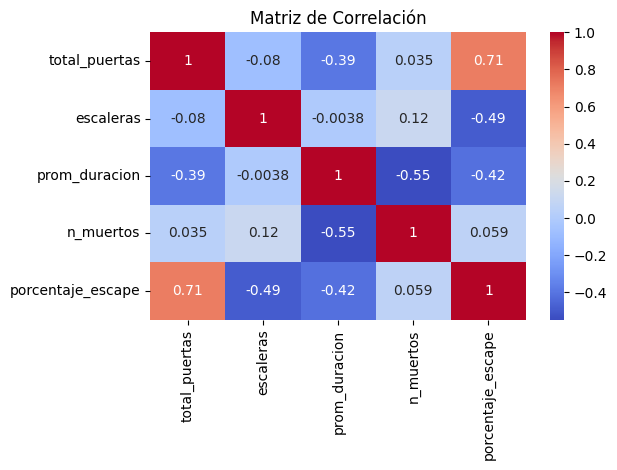

In [ ]:
# Sensibilidad simple
df_corr = df[["total_puertas", "escaleras", "prom_duracion", "n_muertos", "porcentaje_escape"]].corr()
sns.heatmap(df_corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()


C:\Users\ma907\AppData\Local\Temp\ipykernel_54196\3828258451.py:18: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ma907\Music\Data Science III\2do semestre\Simulación\Final\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


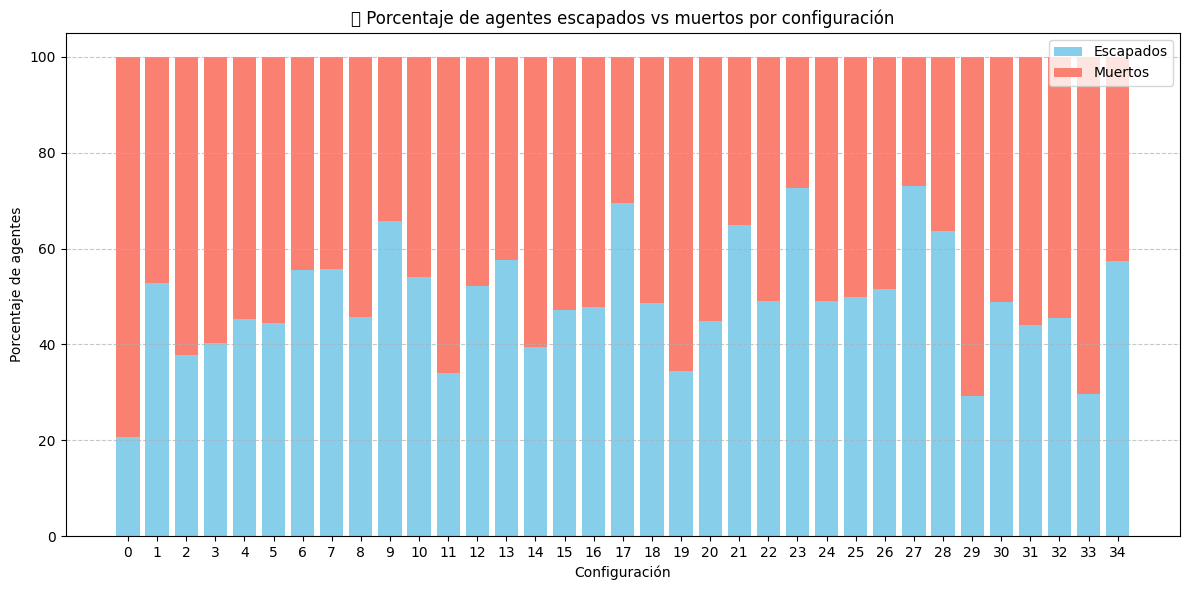

In [ ]:

df["total_agentes"] = df["n_escapados"] + df["n_muertos"]
df["% escapados"] = df["n_escapados"] / df["total_agentes"] * 100
df["% muertos"] = df["n_muertos"] / df["total_agentes"] * 100
df["duración"] = df["prom_duracion"]
df["tiempo_escape"] = df["prom_t_escapes"]

plt.figure(figsize=(12, 6))
plt.bar(df["config_id"], df["% escapados"], label="Escapados", color="skyblue")
plt.bar(df["config_id"], df["% muertos"], bottom=df["% escapados"], label="Muertos", color="salmon")
plt.xlabel("Configuración")
plt.ylabel("Porcentaje de agentes")
plt.title("Porcentaje de agentes escapados vs muertos por configuración")
plt.xticks(df["config_id"])
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\ma907\AppData\Local\Temp\ipykernel_54196\1047860042.py:10: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ma907\Music\Data Science III\2do semestre\Simulación\Final\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


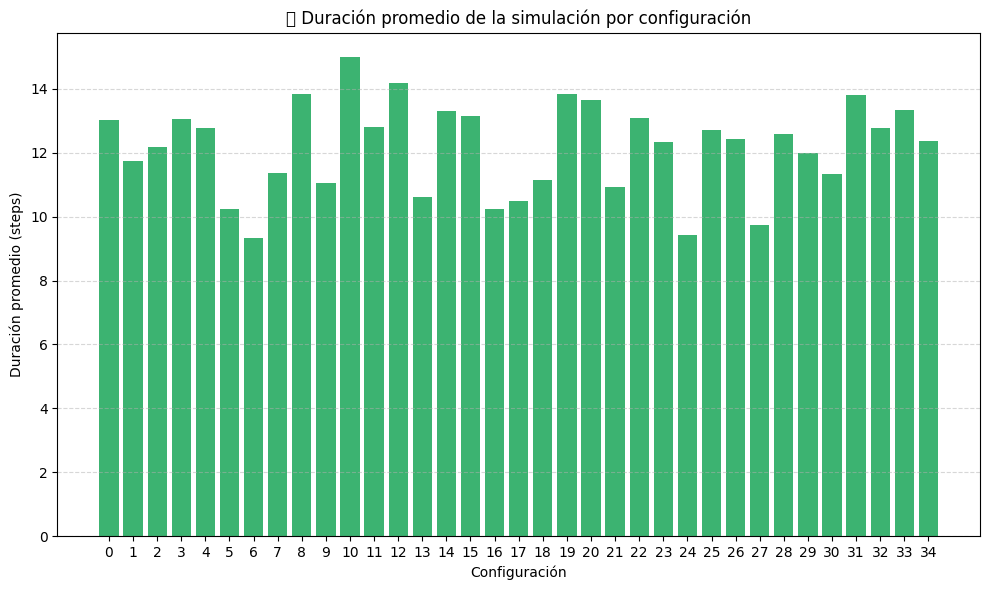

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df["config_id"], df["duración"], color="mediumseagreen")
plt.xlabel("Configuración")
plt.ylabel("Duración promedio (steps)")
plt.title("Duración promedio de la simulación por configuración")
plt.xticks(df["config_id"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\ma907\AppData\Local\Temp\ipykernel_54196\139291057.py:8: UserWarning: Glyph 128682 (\N{DOOR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ma907\Music\Data Science III\2do semestre\Simulación\Final\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128682 (\N{DOOR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


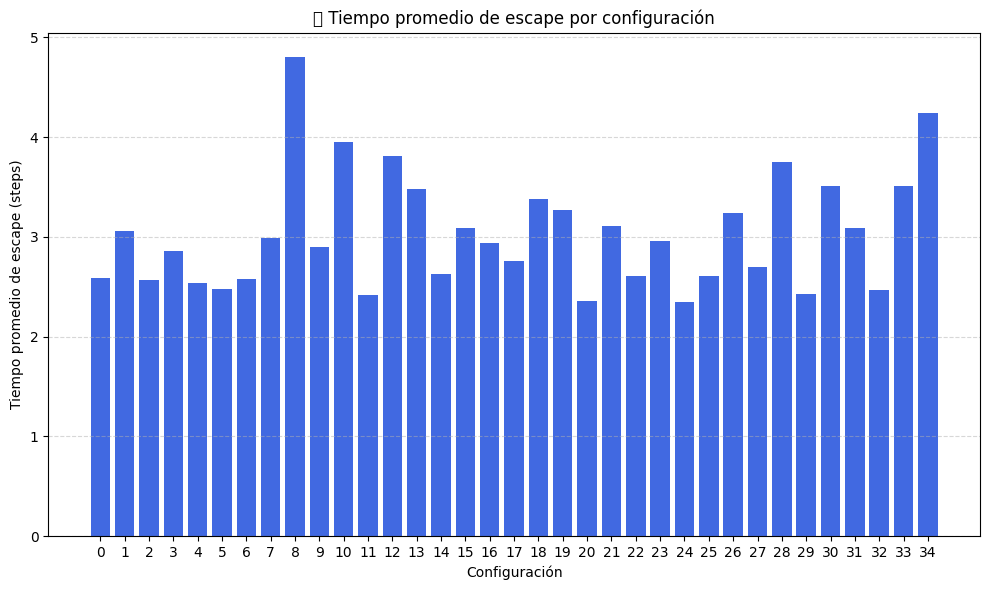

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(df["config_id"], df["tiempo_escape"], color="royalblue")
plt.xlabel("Configuración")
plt.ylabel("Tiempo promedio de escape (steps)")
plt.title("Tiempo promedio de escape por configuración")
plt.xticks(df["config_id"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
